In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("data.csv")

In [3]:
data.info

<bound method DataFrame.info of     Gender      Customer Type  Age   Type of Travel     Class  \
0     Male     Loyal Customer   66  Personal Travel  Business   
1     Male     Loyal Customer   30  Business travel       Eco   
2   Female     Loyal Customer   54  Personal Travel       Eco   
3     Male     Loyal Customer   24  Personal Travel  Eco Plus   
4   Female     Loyal Customer   67  Business travel       Eco   
..     ...                ...  ...              ...       ...   
95  Female     Loyal Customer   64  Personal Travel  Eco Plus   
96  Female     Loyal Customer   27  Business travel  Business   
97  Female     Loyal Customer   41  Business travel  Business   
98    Male     Loyal Customer   54  Business travel  Eco Plus   
99  Female  disloyal Customer   32  Business travel  Business   

    Flight Distance  Inflight wifi service  Departure/Arrival time convenient  \
0              1878                      0                                  1   
1              1031      

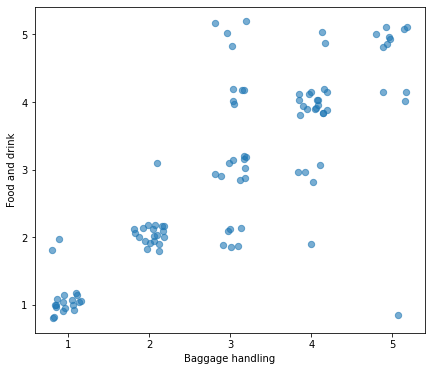

In [4]:
import numpy as np

rng = np.random.default_rng(0)
jitter_x = data['Baggage handling'] + rng.uniform(-0.2, 0.2, len(data))
jitter_y = data['Food and drink'] + rng.uniform(-0.2, 0.2, len(data))

plt.figure(figsize=(7, 6))
plt.scatter(jitter_x, jitter_y, alpha=0.6, s=40)
plt.xlabel('Baggage handling')
plt.ylabel('Food and drink')
plt.show()

In [5]:
def loss_function(m, b, points):
    total_error=0
    for i in range(len(points)):
        x=points.iloc[i]['Baggage handling']
        y=points.iloc[i]['Food and drink']
        total_error += (y-( m * x + b )) ** 2
    return total_error/float(len(points))

In [6]:
def gradient_descent(m_now, b_now, points, L):
    m_gradient=0
    b_gradient=0

    n = len(points)

    for i in range(n):
        x=points.iloc[i]['Baggage handling']
        y=points.iloc[i]['Food and drink']

        m_gradient += -2/n * x * (y- (m_now*x+b_now))
        b_gradient += -2/n * (y- (m_now*x+b_now))

    m = m_now - m_gradient * L
    b = b_now - b_gradient * L
    return m, b

In [7]:
m=0
b=0
L=0.01
epochs=1000

In [8]:
for i in range(epochs):
    m, b = gradient_descent(m, b, data, L)
    if i % 100 == 0:
        print(f"Epoch:{i} loss:{loss_function(m, b, data):.4f} m:{m:.4f} b:{b:.4f}")
print("Final:", m, b)

Epoch:0 loss:6.4166 m:0.1964 b:0.0578
Epoch:100 loss:0.5594 m:0.8892 b:0.2968
Epoch:200 loss:0.5587 m:0.8820 b:0.3217
Epoch:300 loss:0.5584 m:0.8766 b:0.3400
Epoch:400 loss:0.5582 m:0.8727 b:0.3535
Epoch:500 loss:0.5581 m:0.8698 b:0.3634
Epoch:600 loss:0.5580 m:0.8676 b:0.3707
Epoch:700 loss:0.5580 m:0.8661 b:0.3761
Epoch:800 loss:0.5580 m:0.8649 b:0.3801
Epoch:900 loss:0.5580 m:0.8641 b:0.3830
Final: 0.8634338781028449 0.38512243672307633


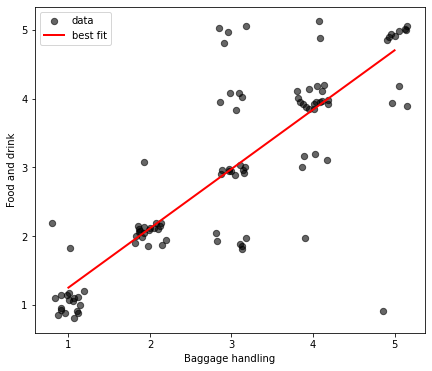

In [9]:
x_min, x_max = data['Baggage handling'].min(), data['Baggage handling'].max()

rng = np.random.default_rng(1)
jitter_x = data['Baggage handling'] + rng.uniform(-0.2, 0.2, len(data))
jitter_y = data['Food and drink'] + rng.uniform(-0.2, 0.2, len(data))

plt.figure(figsize=(7, 6))
plt.scatter(jitter_x, jitter_y, color="black", alpha=0.6, s=40, label="data")
plt.plot([x_min, x_max], [m*x_min+b, m*x_max+b], color="red", linewidth=2, label="best fit")
plt.xlabel('Baggage handling')
plt.ylabel('Food and drink')
plt.legend()
plt.show()